In [124]:
# Import modules
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


## Unzip files

Make sure to unzip the main file into separate zipped files for each station (original download file has a two-level zipped structure)

In [12]:
# Read and inspect zipped files for each station
zipped_files = glob.glob("raw_data/Station_*.zip")
zipped_files


['raw_data\\Station_01(z6-12555)-1774591732.zip',
 'raw_data\\Station_02(z6-12548)-1774591732.zip',
 'raw_data\\Station_03(z6-12556)-1774591732.zip',
 'raw_data\\Station_04(z6-12533)-1774591744.zip',
 'raw_data\\Station_05(z6-12551)-1774591747.zip',
 'raw_data\\Station_06(z6-12552)-1774591747.zip',
 'raw_data\\Station_07(z6-12553)-1774591756.zip',
 'raw_data\\Station_08(z6-12558)-1774591759.zip',
 'raw_data\\Station_09(z6-12557)-1774591759.zip',
 'raw_data\\Station_10(z6-12559)-1774591767.zip',
 'raw_data\\Station_11(z6-12546)-1774591770.zip',
 'raw_data\\Station_12(z6-12544)-1774591770.zip',
 'raw_data\\Station_13(z6-12560)-1774591777.zip',
 'raw_data\\Station_14(z6-12547)-1774591783.zip',
 'raw_data\\Station_15(z6-12554)-1774591783.zip',
 'raw_data\\Station_16(z6-12550)-1774591789.zip']

In [13]:
# Unzip files into station folders
for k,zipped in enumerate(zipped_files):
    with zipfile.ZipFile(zipped, 'r') as file:
        file.extractall(f'raw_data/station_{k+1:02d}')

## Process soil moisture and atmospheric station data

In [163]:
col_names_1 = ['timestamp_utc','vwc_5cm','temp_5cm','ec_5cm','vwc_20cm','temp_20cm','ec_20cm','vwc_40cm','temp_40cm','ec_40cm','temp_air','vapor_pressure','atm_pressure','vpd','precip_total','precip_rate_max','battery_percent','battery_voltage','reference_pressure','temp_logger']
col_names_2 = ['timestamp_utc','vwc_5cm','temp_5cm','ec_5cm','vwc_20cm','temp_20cm','ec_20cm','vwc_40cm','temp_40cm','ec_40cm','solar_rad','precip_total','lightning_activity','lightining_distance','wind_direction','wind_speed','wind_gust','temp_air','vapor_pressure','atm_pressure','x_axis_level','y_axis_level','precip_rate_max','rh_sensor_temp','vpd','battery_percent','battery_voltage','reference_pressure','temp_logger']
col_names_3 = ['timestamp_utc','vwc_5cm','temp_5cm','ec_5cm','vwc_20cm','temp_20cm','ec_20cm','vwc_40cm','temp_40cm','ec_40cm','battery_percent','battery_voltage','reference_pressure','temp_logger']

cols_soil = ['timestamp_utc','vwc_5cm','temp_5cm','ec_5cm','vwc_20cm','temp_20cm','ec_20cm','vwc_40cm','temp_40cm','ec_40cm']
cols_atm = ['timestamp_utc','solar_rad','precip_total','wind_direction','wind_speed','wind_gust','temp_air','vapor_pressure','atm_pressure','precip_rate_max','vpd']

In [165]:
stations = [f"station_{k:02d}" for k in range(1,17)]

for station in stations:
    station_files = [f for f in glob.glob(f'raw_data/{station}/*.csv') if 'Configuration' in f and 'Raw' not in f]
    df_soil_all = pd.DataFrame()
    df_atm_all = pd.DataFrame()
    
    for station_file in station_files:
        df = pd.read_csv(station_file, parse_dates=[0], skiprows=[0,1])

        if ' Sensor Output' in df.columns:
            df.drop(columns=[' Sensor Output'], inplace=True)
            
        if len(df.columns) == 20:
            df = df.rename(columns=dict(zip(df.columns, col_names_1)))
        elif len(df.columns) == 29:
            df = df.rename(columns=dict(zip(df.columns, col_names_2)))
        elif len(df.columns) == 14:
            df = df.rename(columns=dict(zip(df.columns, col_names_3)))
        else:
            print(station_file, 'Headers do not match any default length')
            continue

        # Atmospheric columns
        df_atm = df[[c for c in df.columns if c in cols_atm]]
        df_atm_all = pd.concat([df_atm_all,df_atm])

        # Select soil variables
        df_soil = df.loc[:,cols_soil]
        df_soil_all = pd.concat([df_soil_all,df_soil])

    # Remove duplicate timestamps
    df_atm_all = df_atm_all.drop_duplicates(subset='timestamp_utc')
    df_soil_all = df_soil_all.drop_duplicates(subset='timestamp_utc')

    # Create the complete hourly timestamp range
    full_index = pd.date_range(start=df_soil_all['timestamp_utc'].min(), end=df_soil_all['timestamp_utc'].max(), freq='h')
    
    # Set timestamp as index, reindex, then reset
    df_atm_all = (df_atm_all.set_index('timestamp_utc').reindex(full_index).rename_axis('timestamp_utc').reset_index())
    df_soil_all = (df_soil_all.set_index('timestamp_utc').reindex(full_index).rename_axis('timestamp_utc').reset_index())

    # Save file
    df_atm_all.to_csv(f"atm_data/{station}_atm.csv", index=False)
    df_soil_all.to_csv(f"soil_data/{station}_soil.csv", index=False)

raw_data/station_02\Station_02(z6-12548)-Configuration 2-1774591732.2884884.csv Headers do not match any default length


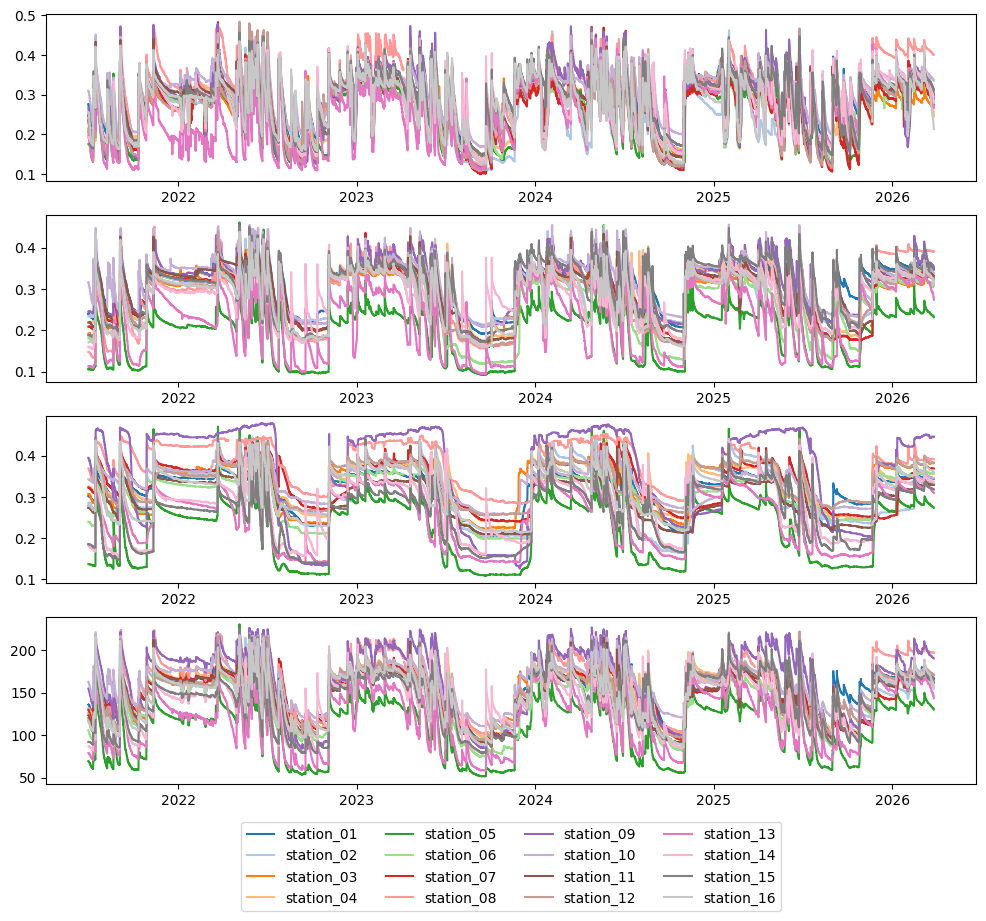

In [145]:
cmap = plt.get_cmap('tab20')


fig, ax = plt.subplots(nrows=4, figsize=(12,10))
for k,station in enumerate(stations):
    df = pd.read_csv(f'soil_data/{station}_soil.csv', parse_dates=['timestamp_utc'])
    storage = df['vwc_5cm'] * 100 + df['vwc_20cm'] * 200 + df['vwc_40cm'] * 200
    
    ax[0].plot(df['timestamp_utc'], df['vwc_5cm'], color=cmap(k))
    ax[1].plot(df['timestamp_utc'], df['vwc_20cm'], color=cmap(k))
    ax[2].plot(df['timestamp_utc'], df['vwc_40cm'], color=cmap(k))
    ax[3].plot(df['timestamp_utc'], storage, color=cmap(k), label=station)

ax[3].legend(loc='lower center', bbox_to_anchor=(0.5, -0.8), ncols=4)
plt.show()

## Get streamflow data

Get data from the USGS

In [173]:
import requests

def usgs_request(start_date):
    """
    start_date in UTC
    Discharge is in cubic feet per second
    P  stands for "Provisional" data subject to revision.
    Example: df = usgs_request('2021-06-28T02:00:00Z')
    """
    
    #start_date = pd.to_datetime(start_date).isoformat() + 'Z'
    url = 'https://waterservices.usgs.gov/nwis/iv/'
    params = {'format': 'rdb', 
              'sites': '06879650', 
              'startDT': start_date, 
              'parameterCd': '00060',
              'siteStatus':'active'}

    response = requests.get(url, params=params)
    return response.content


In [ ]:
results = usgs_request('2021-06-28T02:00:00Z')
results

In [191]:
from io import BytesIO, StringIO

# Decode and filter lines manually
lines = results.decode('utf-8').split('\n')

# Remove comment lines and the format descriptor row ('5s  15s  20d...')
lines = [l for l in lines if not l.startswith('#')]  # drop all comment lines
lines = [l for l in lines if not l.startswith('5s')] # drop the format descriptor row

df_streamflow = pd.read_csv(StringIO('\n'.join(lines)), sep='\t', parse_dates=['datetime'])

df_streamflow.rename(columns={"56608_00060": "discharge_cubic_ft_per_s", "56608_00060_cd": "status"}, inplace=True)

# Change timezone
idx_cdt = df_streamflow['tz_cd'] == 'CDT'
df_streamflow.loc[idx_cdt,'datetime'] = df_streamflow.loc[idx_cdt,'datetime'] + pd.Timedelta('5h')

idx_cst = df_streamflow['tz_cd'] == 'CST'
df_streamflow.loc[idx_cst,'datetime'] = df_streamflow.loc[idx_cst,'datetime'] + pd.Timedelta('6h')

# replace label from CST/CDT to UTC
df_streamflow['tz_cd'] = 'UTC'

# Cubic ft to cubic m per second
df_streamflow['discharge_cubic_m_per_s'] = df_streamflow['discharge_cubic_ft_per_s']*0.0283168 

# Save file
df_streamflow.to_csv('streamflow_data/streamflow_06879650.csv', index=False)
df_streamflow.head()

,agency_cd,site_no,datetime,tz_cd,discharge_cubic_ft_per_s,status,discharge_cubic_m_per_s
0,USGS,6879650,2021-06-28 02:00:00,UTC,0.18,A,0.005097
1,USGS,6879650,2021-06-28 02:15:00,UTC,0.18,A,0.005097
2,USGS,6879650,2021-06-28 02:30:00,UTC,0.18,A,0.005097
3,USGS,6879650,2021-06-28 02:45:00,UTC,0.18,A,0.005097
4,USGS,6879650,2021-06-28 03:00:00,UTC,0.18,A,0.005097


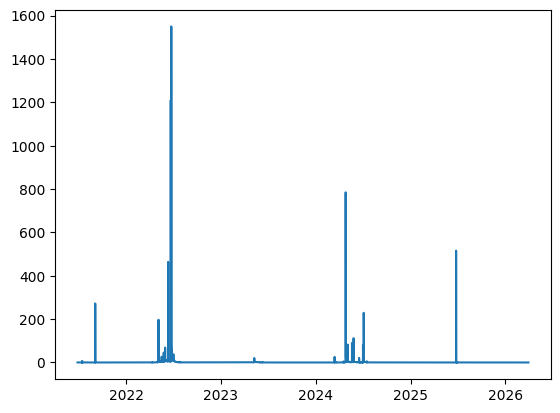

In [189]:
plt.plot(df_streamflow['datetime'], df_streamflow['discharge_cubic_ft_per_s'])

## Get Mesonet data

In [7]:
import ksmesopy.core as meso


In [13]:
variables = ["PRECIP","TEMP2MAVG","RELHUM2MAVG","SRAVG","WDIR2M","WSPD2MAVG"]
df_meso = meso.request_data("Ashland Bottoms", "2021-07-01 00:00:00", "2026-03-27 00:00:00", 'hour', variables)

Requesting 2021-07-01 00:00:00 to 2021-11-03 00:00:00
Requesting 2021-11-03 01:00:00 to 2022-03-08 01:00:00
Requesting 2022-03-08 02:00:00 to 2022-07-11 02:00:00
Requesting 2022-07-11 03:00:00 to 2022-11-13 03:00:00
Requesting 2022-11-13 04:00:00 to 2023-03-18 04:00:00
Requesting 2023-03-18 05:00:00 to 2023-07-21 05:00:00
Requesting 2023-07-21 06:00:00 to 2023-11-23 06:00:00
Requesting 2023-11-23 07:00:00 to 2024-03-27 07:00:00
Requesting 2024-03-27 08:00:00 to 2024-07-30 08:00:00
Requesting 2024-07-30 09:00:00 to 2024-12-02 09:00:00
Requesting 2024-12-02 10:00:00 to 2025-04-06 10:00:00
Requesting 2025-04-06 11:00:00 to 2025-08-09 11:00:00
Requesting 2025-08-09 12:00:00 to 2025-12-12 12:00:00
Requesting 2025-12-12 13:00:00 to 2026-03-27 00:00:00
Done!


In [14]:
df_meso.to_csv('atm_data/ashland_bottoms_ksmesonet.csv', index=False)

## Get vegetation index from Sentinel

In [16]:
import ee

# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize()


Enter verification code:  4/1Aci98E-OBWu8k0xDO6X4UCEmQwBkdO7r1cxSUPMbyUjANX_5JCsBnmzicQM



Successfully saved authorization token.


In [18]:
df_meta = pd.read_csv('stations_metadata.csv')
df_meta

,name,name_alt,latitude,longitude,altitude,serial_number,watershed
0,station_01,Station 1,39.101607,-96.595585,336,z6-12555,AL
1,station_02,Station 2,39.096921,-96.589913,340,z6-12548,N1A
2,station_03,Station 3,39.088371,-96.583513,370,z6-12556,N4D
3,station_04,Station 4,39.085015,-96.571829,412,z6-12533,N1B
4,station_05,Station 5,39.082465,-96.565026,437,z6-12551,N20B
5,station_06,Station 6,39.086729,-96.554463,442,z6-12552,K1B
6,station_07,Station 7,39.092767,-96.574036,408,z6-12553,K1B
7,station_08,Station 8,39.096476,-96.556945,414,z6-12558,K1B
8,station_09,Station 9,39.100208,-96.562427,415,z6-12557,K2A
9,station_10,Station 10,39.102148,-96.579020,359,z6-12559,K1A


In [46]:
start_date =  "2021-07-01"
end_date =  "2026-03-27"

# Define function to create dataframe from GEE data
def array_to_df(arr):
    """Function to convert list into dataframe"""
    df = pd.DataFrame(arr[1:])
    df.columns = arr[0]
    df['time'] = pd.to_datetime(df['time'], unit='ms')
    return df
    
def mask_s2_clouds(image):
    """Mask clouds using the Sentinel-2 Scene Classification Layer (SCL)"""
    scl = image.select('SCL')
    # Keep: 4=vegetation, 5=bare soil, 6=water, 11=snow
    # Exclude: 3=cloud shadow, 8=cloud medium, 9=cloud high, 10=cirrus, 11=snow/ice
    clear = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(clear)

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)



In [47]:
# keep images where CLOUDY_PIXEL_PERCENTAGE < 25

for k,row in df_meta.iterrows():
    print(row['name'])
    point = ee.Geometry.Point([row['longitude'], row['latitude']])
    collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(point).filterDate(start_date, end_date).filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 25)).map(mask_s2_clouds).map(add_ndvi).select('NDVI')
    ndvi = collection.getRegion(point, scale=10).getInfo()
    df_ndvi = array_to_df(ndvi)
    df_ndvi = df_ndvi.dropna(subset=['NDVI'])
    df_ndvi.to_csv(f'vegetation_data/{row['name']}_veg.csv', index=False)

station_01
station_02
station_03
station_04
station_05
station_06
station_07
station_08
station_09
station_10
station_11
station_12
station_13
station_14
station_15
station_16


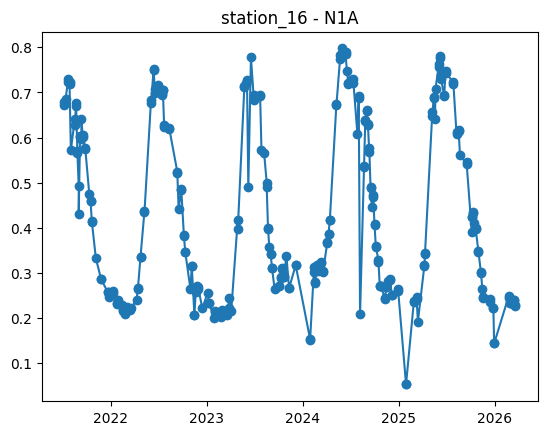

In [51]:
station = 16

station_name = df_meta.loc[station-1,'name']
station_watershed = df_meta.loc[station-1,'watershed']

df_ndvi = pd.read_csv(f'vegetation_data/{station_name}_veg.csv', parse_dates=['time'])
plt.plot(df_ndvi['time'], df_ndvi['NDVI'], 'o-')
plt.title(station_name + " - " + station_watershed)
plt.show()


## Get maps

In [87]:
import geopandas as gpd
import xarray as xr
import rioxarray as rio
import fiona
import requests

# Enable KML support in fiona's supported drivers
fiona.drvsupport.supported_drivers['KML'] = 'rw' 

In [57]:
# Read the KML file into a GeoDataFrame
gdf = gpd.read_file('kings_creek_boundary.kml', driver='KML')

# Export to geojson
gdf.to_file('kings_creek_boundary.geojson', driver="GeoJSON")


<Axes: >

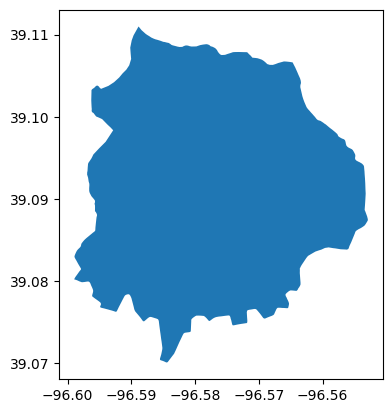

In [56]:
gdf.plot()

In [80]:
def save_geotiff(ee_image, filename, crs, scale, geom, bands=[]):
    """
    Function to save images from Google Earth Engine into local hard drive.
    """
    image_url = ee_image.getDownloadUrl({'region': geom,'scale':scale, 
                                         'bands': bands,
                                         'crs': f'EPSG:{crs}', 
                                         'format': 'GEO_TIFF'})
    
    # Request data using URL and save data as a new GeoTiff file
    response = requests.get(image_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        return print('Saved image')

In [73]:
# Read the file
with open('kings_creek_boundary.geojson') as f:
    roi_json = json.load(f)

geometry = roi_json['features'][0]['geometry']
region = ee.Geometry(geometry)

In [74]:
# Create mask
mask = ee.Image.constant(1).clip(region).mask()

In [100]:
dataset = ee.ImageCollection('USGS/3DEP/10m_collection').filterBounds(region).first().clip(region).mask(mask)


In [105]:
# Terrain derivatives
terrain = ee.Terrain.products(dataset)  # adds slope, aspect, hillshade bands

elevation = terrain.select('elevation')
slope = terrain.select('slope')
aspect = terrain.select('aspect')

In [101]:
elevation = dataset.select('elevation')


In [107]:
save_geotiff(elevation, 'kings_creek_elevation.tif', crs=4326, scale=10, geom=geometry)
save_geotiff(slope, 'kings_creek_slope.tif', crs=4326, scale=10, geom=geometry)
save_geotiff(aspect, 'kings_creek_aspect.tif', crs=4326, scale=10, geom=geometry)


Saved image
Saved image
Saved image


In [108]:
raster_elevation = xr.open_dataarray('kings_creek_elevation.tif').squeeze()
raster_slope = xr.open_dataarray('kings_creek_slope.tif').squeeze()


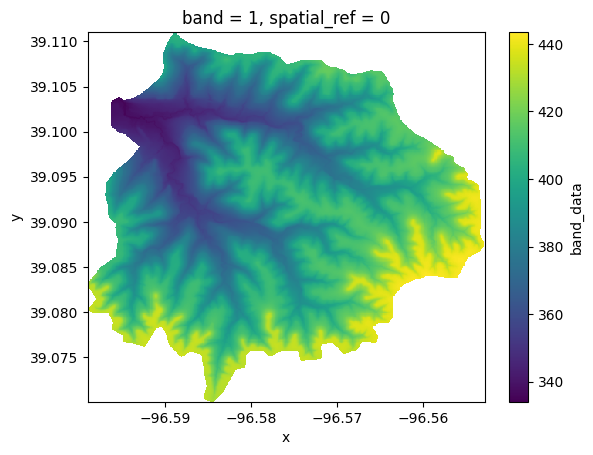

In [109]:
raster_elevation.plot()

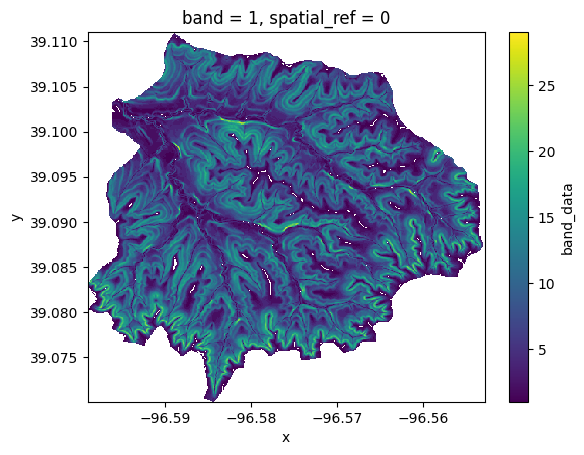

In [110]:
raster_slope.plot()

## Get NDVI images

In [125]:
# Re-define start and end dates based on time series
start_date =  "2021-07-01"
end_date =  "2026-03-27"

# Read the file
with open('kings_creek_boundary.geojson') as f:
    roi_json = json.load(f)

geometry = roi_json['features'][0]['geometry']
region = ee.Geometry(geometry)

# Create mask in GEE for field
mask = ee.Image.constant(1).clip(region).mask()


def mosaic_by_date(date):
    date = ee.Date(date)
    daily = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(region)
               .filterDate(date, date.advance(1, 'day'))
               #.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 25))
               .map(mask_s2_clouds)
               .map(add_ndvi)
               .select('NDVI')
               .mosaic()                # merges overlapping tiles for that day
               .clip(region))
    return daily.set('system:time_start', date.millis())

# Get unique dates
dates = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(region)
           .filterDate(start_date, end_date)
           .aggregate_array('system:time_start')
           .map(lambda t: ee.Date(t).format('YYYY-MM-dd'))
           .distinct())

collection = ee.ImageCollection(dates.map(mosaic_by_date))

In [128]:
# Get the list of available image dates
get_date = lambda image: ee.Image(image).date().format('YYYY-MM-dd')

collection_dates = collection.toList(collection.size()).map(get_date).getInfo()
unique_collection_dates = np.unique(collection_dates)

# Select a subset of the collection dates to download
selected_dates = unique_collection_dates[::1]
print('Selected dates:')
print(selected_dates)



Selected dates:
['2021-07-03' '2021-07-08' '2021-07-13' '2021-07-18' '2021-07-23'
 '2021-07-28' '2021-08-02' '2021-08-07' '2021-08-12' '2021-08-17'
 '2021-08-22' '2021-08-27' '2021-09-01' '2021-09-06' '2021-09-11'
 '2021-09-16' '2021-09-21' '2021-09-26' '2021-10-01' '2021-10-06'
 '2021-10-11' '2021-10-16' '2021-10-21' '2021-10-26' '2021-10-31'
 '2021-11-05' '2021-11-10' '2021-11-15' '2021-11-20' '2021-11-25'
 '2021-11-30' '2021-12-05' '2021-12-10' '2021-12-15' '2021-12-20'
 '2021-12-25' '2021-12-30' '2022-01-04' '2022-01-09' '2022-01-14'
 '2022-01-19' '2022-01-24' '2022-01-29' '2022-02-03' '2022-02-08'
 '2022-02-13' '2022-02-18' '2022-02-23' '2022-02-28' '2022-03-05'
 '2022-03-10' '2022-03-15' '2022-03-20' '2022-03-25' '2022-03-30'
 '2022-04-04' '2022-04-09' '2022-04-14' '2022-04-19' '2022-04-24'
 '2022-05-04' '2022-05-09' '2022-05-14' '2022-05-19' '2022-05-24'
 '2022-05-29' '2022-06-03' '2022-06-08' '2022-06-13' '2022-06-18'
 '2022-06-23' '2022-06-28' '2022-07-03' '2022-07-08' '2022-0

In [ ]:
for date in selected_dates:
    start = date
    end = (datetime.strptime(date, '%Y-%m-%d') + timedelta(days=1)).strftime('%Y-%m-%d')

    # Rebuild mosaic for that date to ensure full watershed coverage
    image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(roi_geom)
               .filterDate(start, end)
               .map(mask_s2_clouds)
               .map(add_ndvi)
               .select('NDVI')
               .mosaic()
               .clip(roi_geom)
               .mask(mask))

    save_geotiff(image, f'ndvi_maps/ndvi_{date}.tif', crs=4326, scale=10, geom=region)

In [144]:
files = glob.glob(f'ndvi_maps/*.tif')

for file in files:
    raster = xr.load_dataarray(file)
    nans = round(np.sum(np.isnan(raster)).values/raster.size*100)
    if nans > 38:
        glob.os.remove(file)
        print('Removed:',file,':',nans)

Removed: ndvi_maps\ndvi_2021-07-03.tif : 40
Removed: ndvi_maps\ndvi_2022-10-26.tif : 39
Removed: ndvi_maps\ndvi_2023-06-28.tif : 40
Removed: ndvi_maps\ndvi_2025-08-21.tif : 39
Removed: ndvi_maps\ndvi_2025-09-15.tif : 39
